# Учебный ноутбук: госзакупки через минимизацию и теневые цены

## Что здесь происходит как единая система

Здесь не набор отдельных задач, а один связный процесс внутреннего контроля закупок:

1. сначала считаем эталон минимально возможной стоимости закупки;
2. затем извлекаем fair-ориентиры по видам продукции через двойственную задачу;
3. отдельно по каждому виду продукции считаем fair-ориентиры по сырью;
4. потом сравниваем модельные fair-ориентиры с фактическими контрактными ценами;
5. получаем сумму потенциального завышения и приоритет проверки.

По-человечески это значит: модель отвечает на вопрос «сколько это должно стоить в нормальной структуре ограничений», а аудит сравнивает этот ориентир с реальными ценами в документах.

Важно: результат — индикатор риска для контроля закупок, а не автоматическое юридическое обвинение.

## 0. Мини-словарь простыми словами

- **Минимизация закупки**: выбираем объёмы закупки так, чтобы закрыть потребности с минимальной суммой затрат.
  По-человечески это значит: ищем самый экономный план при реальных лимитах.
- **Двойственная задача**: зеркальная математическая форма исходной задачи, которая показывает внутренние оценки ограничений.
  По-человечески это значит: модель сама подсказывает «справедливые» ориентиры цен.
- **Теневая цена продукции $\pi_j$**: внутренняя оценка единицы продукта $j$ в системе закупок.
- **Теневая цена сырья $\mu_{i,j}$**: внутренняя оценка единицы сырья $i$ именно в контексте продукта $j$.
- **Fair-ориентир**: модельная цена, с которой сравниваем факт.
- **Риск-флаг**: уровень приоритета проверки (`green`/`yellow`/`red`).

## 0.1. Как связаны все задачи в одном конвейере

### Пошаговый pipeline (1–6)

1. Собираем входные данные закупок: спрос, цены поставщиков, лимиты поставок.
2. Решаем **Primal-P** и получаем эталон закупки: $Q^*$ и $C_{\min}$.
3. Решаем **Dual-DP** и получаем тени продукции: $\pi$.
4. Решаем 3 отдельные сырьевые LP и получаем тени сырья: $\mu_{i,j}$.
5. Считаем завышения: по продукции через $\pi$, по сырью через $\mu_{i,j}$.
6. Складываем риск-объём, ставим флаги и ранжируем, что проверять первым.

### Таблица зависимостей

| Шаг | Входные данные | Математическая задача | Выход | Куда идёт дальше |
|---|---|---|---|---|
| 1 | $d, P, U$ | Подготовка постановки | Формальные ограничения | В Primal-P |
| 2 | $d, P, U$ | Primal-P | $Q^*, C_{\min}$ | На проверку согласованности с dual |
| 3 | $d, P, U$ | Dual-DP | $\pi$ | В аудит цен продукции |
| 4 | $D_j, c_j, A_j, R_j$ | 3 сырьевых LP | $\mu_{i,j}$ | В аудит цен сырья |
| 5 | Факт цен + $\pi, \mu$ | Формулы переплат | $overpay_{product}, overpay_{raw}$ | В сводный отчёт |
| 6 | Две суммы переплат | Агрегация и флаги | $total\_risk$ и приоритеты | В управленческие действия |

Ключевая зависимость: без $\pi$ нельзя корректно оценить завышение по продукции; без $\mu_{i,j}$ нельзя корректно оценить завышение по сырью в контексте конкретного продукта.

## 1. Основная задача госзакупки (Primal-P)

### Что решаем
Ищем такой план закупки, который закрывает потребности учреждения и даёт минимальную общую стоимость.

### Какие данные входят
- $d_j$ — требуемый объём продукта $j$;
- $p_{s,j}$ — цена продукта $j$ у поставщика $s$;
- $u_{s,j}$ — верхний лимит поставки по паре «поставщик $s$ — продукт $j$».

Пусть $q_{s,j}$ — объём закупки продукта $j$ у поставщика $s$.

$$
\min C = \sum_{s=1}^{3}\sum_{j=1}^{3} p_{s,j}q_{s,j}
$$

Здесь $C$ — общая стоимость закупки; каждое слагаемое $p_{s,j}q_{s,j}$ — «цена за единицу × количество» по одной паре поставщик–продукт.

### Как формула конструируется (пошагово)

1. **Что оптимизируем (бытовой смысл).** Учреждение хочет купить нужные объёмы как можно дешевле.
2. **Из чего складывается сумма.** Складываем стоимость по всем поставщикам и всем продуктам: двойная сумма по индексам $s$ и $j$.
3. **Почему знак именно `min`.** Цель закупки — уменьшить расходы, а не увеличить их.
4. **Почему такие коэффициенты.** Коэффициенты в цели — это реальные контрактные цены $p_{s,j}$.
5. **Проверка размерности.** Цена (денежная единица/шт.) × объём (шт.) = деньги; сумма денег по всем позициям даёт общий бюджет закупки.
6. **Типичная ошибка.** Поставить `max` вместо `min` и получить математически корректный, но экономически абсурдный «самый дорогой» план.

### Почему знаки в ограничениях именно такие

$$
\sum_{s=1}^{3} q_{s,j} \ge d_j,\quad j=1,2,3
$$

Здесь знак $\ge$ нужен потому, что спрос нужно покрыть не меньше обязательного уровня.

$$
0 \le q_{s,j} \le u_{s,j},\quad s=1,2,3,\ j=1,2,3
$$

Здесь знак $\le$ справа нужен потому, что поставщик физически не может поставить больше лимита $u_{s,j}$, а знак $\ge 0$ слева исключает отрицательные объёмы закупки.

### Исходные данные

$$
d = (300,\ 220,\ 180)
$$

$$
P = \begin{pmatrix}
95 & 88 & 120 \\
102 & 84 & 118 \\
98 & 90 & 116
\end{pmatrix},\quad
U = \begin{pmatrix}
180 & 120 & 120 \\
160 & 140 & 80 \\
100 & 80 & 120
\end{pmatrix}
$$

Здесь $P$ — матрица цен; $U$ — матрица лимитов поставки.

### Что выходит
- $Q^*$ — оптимальная матрица закупок;
- $C_{\min}$ — минимально достижимая стоимость закупки.

### Как это используется дальше
Этот шаг даёт базовую экономическую рамку; в dual-задаче из неё извлекаются fair-ориентиры по продуктам ($\pi$).

## 2. Двойственная задача к основной закупке (Dual-DP)

### Что решаем
Получаем внутренние оценки системы закупок, чтобы вывести fair-ориентиры по видам продукции.

Обозначим:
- $\pi_j$ — теневая цена единицы продукта $j$;
- $\nu_{s,j}$ — теневая оценка ограничения по лимиту поставки $u_{s,j}$.

$$
\max \Psi = \sum_{j=1}^{3} d_j\pi_j - \sum_{s=1}^{3}\sum_{j=1}^{3} u_{s,j}\nu_{s,j}
$$

### Как формула конструируется (пошагово)

1. **Что оптимизируем (бытовой смысл).** Ищем внутреннюю оценку системы: сколько «стоит» покрытие спроса с учётом ограничений.
2. **Из чего складывается сумма.** Первый блок $\sum d_j\pi_j$ — вклад покрытия спроса; второй блок $\sum u_{s,j}\nu_{s,j}$ — вклад жёсткости лимитов.
3. **Почему знак `max`.** В dual мы ищем максимально возможную нижнюю оценку исходной минимизационной задачи (стандартная dual-логика для primal-min с ограничениями такого типа).
4. **Почему один блок со знаком `+`, а второй со знаком `-`.** Покрытие спроса увеличивает ценность системы, а жёсткие лимиты поставки «съедают» эту ценность, поэтому вычитаются.
5. **Почему такие коэффициенты.** В коэффициентах стоят реальные масштабы ограничений из primal: $d_j$ и $u_{s,j}$.
6. **Типичная ошибка.** Поставить `+ \sum u_{s,j}\nu_{s,j}` и получить неверную экономическую интерпретацию: лимиты начнут «улучшать» цель вместо ограничения.

### Почему знаки ограничений именно такие

$$
\pi_j - \nu_{s,j} \le p_{s,j},\quad s=1,2,3,\ j=1,2,3
$$

Здесь знак $\le$ удерживает внутреннюю оценку в рамках наблюдаемой цены $p_{s,j}$. По-человечески: модель не должна считать продукт дороже, чем допускает ценовая матрица и лимиты.

$$
\pi_j \ge 0,\quad \nu_{s,j} \ge 0
$$

Ненегативность означает, что внутренние оценки не трактуются как «отрицательная ценность».

### Откуда берётся dual-целевая функция (интуитивно)

- $\pi_j$ — ценность покрытия потребности по продукту $j$;
- $\nu_{s,j}$ — «цена жёсткости» лимита $u_{s,j}$;
- поэтому итоговая dual-оценка: «ценность покрытия спроса» минус «штраф ограниченности поставок».

### Проверка здравого смысла

- если лимит $u_{s,j}$ сделать жёстче, система обычно должна становиться дороже;
- если спрос $d_j$ увеличить, минимальная стоимость закупки не должна уменьшаться.

### Что выходит
- вектор $\pi$ как fair-ориентир по видам продукции;
- оценки $\nu_{s,j}$ как чувствительность к лимитам поставки.

### Как это используется дальше
Именно $\pi_j$ используется в формуле детекта завышения по продуктам.

## 3. Отдельные задачи по сырью для каждого продукта

### Что решаем
Для каждого продукта отдельно считаем минимальную стоимость обеспечения выпуска через доступные маршруты и определяем, какое сырьё реально дефицитно.

Для продукта $j$:

$$
\min F_j = \sum_{t=1}^{3} c_{j,t}x_{j,t}
$$

### Как формула конструируется (пошагово)

1. **Что оптимизируем (бытовой смысл).** Для одного продукта выбираем самый экономный способ собрать требуемый объём.
2. **Из чего складывается сумма.** По всем маршрутам $t$: стоимость маршрута $c_{j,t}$ умножается на объём по маршруту $x_{j,t}$.
3. **Почему знак `min`.** Это задача затрат: выбираем минимальную стоимость обеспечения продукта.
4. **Почему такие коэффициенты.** $c_{j,t}$ — прямые стоимостные параметры маршрутов из исходных данных.
5. **Проверка размерности.** Стоимость маршрута (денежная единица/объём) × объём маршрута = деньги; сумма по маршрутам даёт $F_j$.
6. **Типичная ошибка.** Путать индексы и суммировать не по маршрутам, а по сырью; тогда цель перестаёт соответствовать данным.

### Почему знаки ограничений именно такие

$$
\sum_{t=1}^{3} x_{j,t} \ge D_j
$$

Знак $\ge$ нужен, потому что продукта должно быть не меньше требуемого объёма $D_j$.

$$
\sum_{t=1}^{3} a_{i,j,t}x_{j,t} \le R_{i,j},\quad i=1,2,3
$$

Знак $\le$ нужен, потому что расход сырья не может превышать доступный лимит $R_{i,j}$.

$$
x_{j,t} \ge 0
$$

Отрицательный выпуск по маршруту невозможен физически.

### Dual-интерпретация для сырья

Dual этой задачи даёт $\mu_{i,j}$.

- если $\mu_{i,j}>0$, сырьё $i$ критично для продукта $j$ (дефицитно в оптимуме);
- если $\mu_{i,j}=0$, это сырьё в текущем режиме не ограничивает минимум.

### Что выходит
Для каждого продукта: $F_j^*$ и вектор $\mu_{i,j}$.

### Как это используется дальше
$\mu_{i,j}$ идёт прямо в формулу детекта завышения сырья.

### Числовые данные для трёх отдельных задач

Продукт 1:

$$
D_1=120,\quad c_1=(60,66,72),\quad
A_1=\begin{pmatrix}3&1&2\\1&3&2\\1&1&2\end{pmatrix},\quad R_1=(250,260,220)
$$

Продукт 2:

$$
D_2=100,\quad c_2=(50,56,62),\quad
A_2=\begin{pmatrix}1&2&1\\3&1&2\\1&1&2\end{pmatrix},\quad R_2=(260,180,260)
$$

Продукт 3:

$$
D_3=90,\quad c_3=(78,84,90),\quad
A_3=\begin{pmatrix}1&1&2\\1&2&1\\3&1&2\end{pmatrix},\quad R_3=(220,220,190)
$$

Что мы получили и зачем это дальше: эти параметры сразу передаются в функции решения трёх сырьевых LP, чтобы получить $\mu_{i,j}$ и затем сделать аудит сырья.

## 3.1. Переход к формату `linprog` без магии

`scipy.optimize.linprog` ожидает задачу минимизации в формате:

$$
\min c^T x \quad \text{при} \quad A_{ub}x \le b_{ub},\ A_{eq}x=b_{eq},\ l\le x\le u
$$

Поэтому делаем стандартные преобразования.

### Преобразование 1: `>=` в `<=`

Если есть ограничение спроса

$$
\sum_s q_{s,j} \ge d_j,
$$

то для `A_ub` переписываем как

$$
-\sum_s q_{s,j} \le -d_j.
$$

Мини-пример на 1 строку: `q1 + q2 >= 10` превращаем в `-q1 - q2 <= -10`.

### Преобразование 2: `max` в `min`

Если в математике цель записана как максимум

$$
\max g(x),
$$

то в `linprog` подаём

$$
\min (-g(x)).
$$

Мини-пример: `max (2x)` эквивалентно `min (-2x)`.

### Где это отражено в коде

- `c` — коэффициенты целевой функции для минимизации;
- `A_ub`, `b_ub` — все неравенства приведены к виду `<=`;
- `bounds` — границы переменных (обычно `(0, None)` для неотрицательности).

Типичная ошибка: забыть сменить знак хотя бы у одной части (`c`, `A_ub`, `b_ub`) и получить формально решённую, но экономически неверную задачу.

## 4. Python: подготовка среды и визуального стиля

### Что делаем сейчас
Подключаем библиотеки и настраиваем аккуратный визуальный стиль таблиц и графиков.

### Что получим на выходе
Единый читаемый формат всех дальнейших расчётов и отчётных иллюстраций.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import linprog

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["axes.titlesize"] = 13
plt.rcParams["axes.labelsize"] = 11
plt.rcParams["legend.fontsize"] = 10

pd.set_option("display.precision", 4)


def risk_flag(pct: float) -> str:
    if pct > 25:
        return "red"
    if pct > 10:
        return "yellow"
    return "green"


def show_df(df: pd.DataFrame, caption: str = "") -> None:
    try:
        from IPython.display import display

        styler = df.style.format(precision=2)
        numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
        if numeric_cols:
            styler = styler.background_gradient(cmap="Blues", subset=numeric_cols)
        if caption:
            styler = styler.set_caption(caption)
        display(styler)
    except Exception:
        if caption:
            print() 
            print(caption)
        print(df)


## 5. Функция решения основной закупочной задачи и её dual

### На что смотреть при чтении функции

- В блоке primal цель `c = P.flatten()` уже соответствует минимизации `\min C`.
- Ограничения спроса переводятся из `>=` в `<=` умножением на `-1` перед заполнением `A_ub`, `b_ub`.
- Ограничения лимитов поставки сразу имеют вид `<=`, поэтому входят в `A_ub` без смены знака.
- В dual есть цель максимизации, поэтому в коде она задаётся как минимизация противоположной функции (`c_dual` со сменой знака у блока спроса).

По-человечески это значит: функция не «придумывает» математику заново, а аккуратно переводит бумажную постановку в язык, который понимает `linprog`.

In [2]:
def solve_procurement_primal_dual(d: np.ndarray, P: np.ndarray, U: np.ndarray) -> dict:
    n_sup, n_prod = P.shape

    # ===== Primal-P: min sum p_{s,j} q_{s,j} =====
    c = P.flatten()

    A_ub = []
    b_ub = []

    # demand: sum_s q_{s,j} >= d_j  ->  -sum_s q_{s,j} <= -d_j
    for j in range(n_prod):
        row = np.zeros(n_sup * n_prod)
        for s in range(n_sup):
            row[s * n_prod + j] = -1.0
        A_ub.append(row)
        b_ub.append(-d[j])

    # capacities: q_{s,j} <= u_{s,j}
    for s in range(n_sup):
        for j in range(n_prod):
            row = np.zeros(n_sup * n_prod)
            row[s * n_prod + j] = 1.0
            A_ub.append(row)
            b_ub.append(U[s, j])

    A_ub = np.array(A_ub, dtype=float)
    b_ub = np.array(b_ub, dtype=float)
    bounds = [(0, None)] * (n_sup * n_prod)

    res_primal = linprog(c, A_ub=A_ub, b_ub=b_ub, bounds=bounds, method="highs")

    # ===== Dual-DP =====
    # max Psi = d*pi - U*nu
    # s.t. pi_j - nu_{s,j} <= p_{s,j}, pi>=0, nu>=0
    # to linprog(min): min -d*pi + U*nu
    c_dual = np.concatenate([-d, U.flatten()]).astype(float)

    A_ub_dual = []
    b_ub_dual = []
    for s in range(n_sup):
        for j in range(n_prod):
            row = np.zeros(n_prod + n_sup * n_prod)
            row[j] = 1.0  # pi_j
            row[n_prod + s * n_prod + j] = -1.0  # -nu_{s,j}
            A_ub_dual.append(row)
            b_ub_dual.append(P[s, j])

    A_ub_dual = np.array(A_ub_dual, dtype=float)
    b_ub_dual = np.array(b_ub_dual, dtype=float)
    bounds_dual = [(0, None)] * (n_prod + n_sup * n_prod)

    res_dual = linprog(
        c_dual,
        A_ub=A_ub_dual,
        b_ub=b_ub_dual,
        bounds=bounds_dual,
        method="highs",
    )

    result = {
        "res_primal": res_primal,
        "res_dual": res_dual,
        "Q_opt": res_primal.x.reshape(n_sup, n_prod),
        "C_min": res_primal.fun,
        "pi": res_dual.x[:n_prod],
        "nu": res_dual.x[n_prod:].reshape(n_sup, n_prod),
        "Psi_max": -res_dual.fun,
        "strong_duality_ok": np.isclose(res_primal.fun, -res_dual.fun),
    }
    return result

## 6. Запуск основной пары задач и проверка ориентиров

### Что решаем
Запускаем Primal-P и Dual-DP на одинаковых данных.

### Какие данные входят
Массивы спроса $d$, цен $P$ и лимитов $U$.

### Что выходит
- $Q^*, C_{\min}$ из Primal-P;
- $\pi, \Psi_{\max}$ из Dual-DP;
- проверка сильной двойственности `np.isclose(C_min, Psi_max)`.

### Как это используется дальше
Из этого шага в аудит продукции уходит именно $\pi$.

### Что сломается в логике, если шаг пропустить
Без численного решения и проверки двойственности у нас не будет подтверждённого fair-ориентира по продукции.

In [3]:
d = np.array([300.0, 220.0, 180.0], dtype=float)
P = np.array(
    [
        [95.0, 88.0, 120.0],
        [102.0, 84.0, 118.0],
        [98.0, 90.0, 116.0],
    ],
    dtype=float,
)
U = np.array(
    [
        [180.0, 120.0, 120.0],
        [160.0, 140.0, 80.0],
        [100.0, 80.0, 120.0],
    ],
    dtype=float,
)

main_sol = solve_procurement_primal_dual(d, P, U)

Q_opt = main_sol["Q_opt"]
C_min = main_sol["C_min"]
pi = main_sol["pi"]
Psi_max = main_sol["Psi_max"]

print("Основная задача решена успешно (True/False):", main_sol["res_primal"].success)
print("Двойственная задача решена успешно (True/False):", main_sol["res_dual"].success)
print("Минимальная стоимость закупки C_min:", C_min)
print("Значение двойственной цели Psi_max:", Psi_max)
print("Проверка сильной двойственности (должно быть True):", main_sol["strong_duality_ok"])
print()
print("Оптимальная матрица закупок Q*:")
print(Q_opt)
print()
print("Теневые цены видов продукции pi*:", pi)

Основная задача решена успешно (True/False): True
Двойственная задача решена успешно (True/False): True
Минимальная стоимость закупки C_min: 68740.0
Значение двойственной цели Psi_max: 68740.0
Проверка сильной двойственности (должно быть True): True

Оптимальная матрица закупок Q*:
[[180.  80.   0.]
 [ 20. 140.  60.]
 [100.   0. 120.]]

Теневые цены видов продукции pi*: [102.  88. 118.]


### Интерпретация результата основной пары

Ожидаемые контрольные значения:

$$
Q^*=\begin{pmatrix}
180 & 80 & 0 \\
20 & 140 & 60 \\
100 & 0 & 120
\end{pmatrix},\quad C_{\min}=68740
$$

$$
\pi^*=(102,\ 88,\ 118),\quad \Psi_{\max}=68740
$$

Здесь $\pi_1=102$ означает: дополнительная единица спроса по продукту 1 увеличивает минимальную закупочную стоимость примерно на 102 при текущих ограничениях.

Что мы получили и зачем это в следующем шаге: теперь у нас есть fair-ориентир по продуктам $\pi$, поэтому можно переходить к анализу сырья и потом к сравнению «факт против модели».

### Куда смотреть после этапа: основная пара Primal-P + Dual-DP

#### Ключевые числа этапа

| Метрика | Формула-источник | Где видно в коде/выводе | Ожидаемое значение | Критичный знак | Как трактовать отклонение |
|---|---|---|---|---|---|
| `C_min` | $\min C = \sum p_{s,j}q_{s,j}$ | Печать `Минимальная стоимость закупки C_min` | `68740` | `min` | Если выше ожидаемого при тех же данных — ошибка постановки/кода |
| `Psi_max` | $\max \Psi = \sum d_j\pi_j - \sum u_{s,j}\nu_{s,j}$ | Печать `Psi_max` | `68740` | `max` и `-\sum u\nu` | Если не совпадает с `C_min`, нарушена связка primal/dual |
| `pi*` | Dual-DP | Печать `pi*` | `(102, 88, 118)` | Ограничения dual с `$\le$` | Это fair-ориентир по продуктам для аудита |
| `Q*` | Ограничения primal | Печать матрицы `Q*` | фиксированная матрица | спрос `$\ge$`, лимиты `$\le$` | Несогласованность с лимитами = неверная модель |

#### Быстрый маршрут чтения формулы -> числа -> вывод
1. Смотрите формулу `\min C` и проверяйте `C_min`.
2. Смотрите dual-формулу и проверяйте `Psi_max`.
3. Если `C_min == Psi_max`, берите `pi*` как fair-цены продукции для следующего шага.

## 7. Наглядные таблицы и график структуры оптимальной закупки

,product_1,product_2,product_3
supplier_1,180.00,80.00,0.00
supplier_2,20.00,140.00,60.00
supplier_3,100.00,0.00,120.00


,product,shadow_price_pi
0,product_1,102.00
1,product_2,88.00
2,product_3,118.00


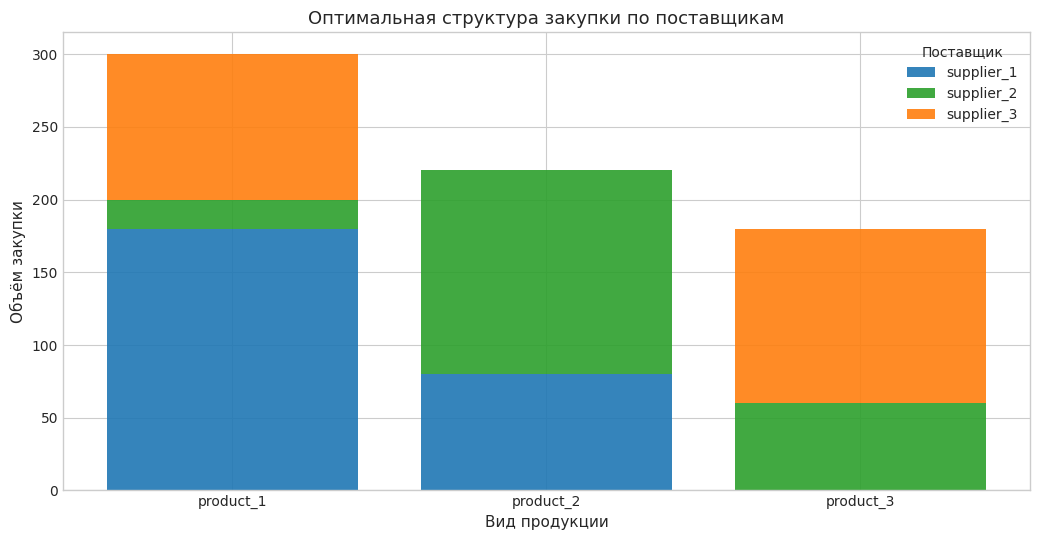

In [4]:
products = ["product_1", "product_2", "product_3"]
suppliers = ["supplier_1", "supplier_2", "supplier_3"]

q_df = pd.DataFrame(Q_opt, index=suppliers, columns=products)
price_df = pd.DataFrame(P, index=suppliers, columns=products)
cap_df = pd.DataFrame(U, index=suppliers, columns=products)
pi_df = pd.DataFrame({"product": products, "shadow_price_pi": pi})

show_df(q_df.round(2), "Оптимальная матрица закупок Q*")
show_df(pi_df.round(2), "Теневые цены видов продукции (pi)")

# Stacked bar: кто закрывает спрос по каждому продукту
fig, ax = plt.subplots(figsize=(10.5, 5.5))
bottom = np.zeros(len(products))
colors = ["#1f77b4", "#2ca02c", "#ff7f0e"]
for i, s in enumerate(suppliers):
    vals = q_df.loc[s].values
    ax.bar(products, vals, bottom=bottom, label=s, color=colors[i], alpha=0.9)
    bottom += vals

ax.set_title("Оптимальная структура закупки по поставщикам")
ax.set_xlabel("Вид продукции")
ax.set_ylabel("Объём закупки")
ax.legend(title="Поставщик")
plt.tight_layout()
plt.show()

## 8. Функция решения сырьевой задачи для одного продукта

### Что решаем
Для каждого продукта отдельно запускаем пару primal/dual по сырью.

### Какие данные входят
$D_j, c_j, A_j, R_j$ для конкретного продукта.

### Что выходит
- $F_j^*$ — минимальная стоимость обеспечения продукта;
- $\lambda_j$ — dual-оценка по ограничению спроса;
- $\mu_{i,j}$ — dual-оценки по сырьевым ограничениям.

### Как это используется дальше
В аудит сырья уходит именно матрица $\mu_{i,j}$.

### Что сломается в логике, если шаг пропустить
Без этой функции не получится масштабируемо и одинаково посчитать fair-ориентиры сырья для всех продуктов.

In [5]:
def solve_raw_lp_for_product(
    D_j: float,
    c_j: np.ndarray,
    A_j: np.ndarray,
    R_j: np.ndarray,
    product_name: str,
) -> dict:
    # ===== Primal for one product =====
    # min c_j * x
    # sum x >= D_j  -> -sum x <= -D_j
    # A_j x <= R_j
    A_ub = [
        -np.ones(3, dtype=float),
        A_j[0],
        A_j[1],
        A_j[2],
    ]
    b_ub = np.array([-D_j, R_j[0], R_j[1], R_j[2]], dtype=float)

    res_primal = linprog(
        c_j,
        A_ub=np.array(A_ub, dtype=float),
        b_ub=b_ub,
        bounds=[(0, None)] * 3,
        method="highs",
    )

    # ===== Dual for one product =====
    # max D_j*lambda - R_j*mu
    # s.t. lambda - sum_i a_{i,t}*mu_i <= c_t
    # lambda>=0, mu>=0
    c_dual = np.array([-D_j, R_j[0], R_j[1], R_j[2]], dtype=float)

    A_ub_dual = []
    b_ub_dual = []
    for t in range(3):
        row = np.zeros(4, dtype=float)
        row[0] = 1.0
        row[1:] = -A_j[:, t]
        A_ub_dual.append(row)
        b_ub_dual.append(c_j[t])

    res_dual = linprog(
        c_dual,
        A_ub=np.array(A_ub_dual, dtype=float),
        b_ub=np.array(b_ub_dual, dtype=float),
        bounds=[(0, None)] * 4,
        method="highs",
    )

    return {
        "product": product_name,
        "res_primal": res_primal,
        "res_dual": res_dual,
        "x_opt": res_primal.x,
        "F_min": res_primal.fun,
        "lambda": res_dual.x[0],
        "mu": res_dual.x[1:],
        "dual_max": -res_dual.fun,
        "strong_duality_ok": np.isclose(res_primal.fun, -res_dual.fun),
    }

## 9. Запуск трёх сырьевых задач

### Что решаем
Последовательно считаем три отдельные сырьевые задачи: для `product_1`, `product_2`, `product_3`.

### Какие данные входят
Словарь `raw_problem_data` с параметрами каждого продукта.

### Что выходит
Таблица `raw_summary` с $F_j^*$, $\lambda_j$, $\mu_{i,j}$ и проверкой сильной двойственности.

### Как это используется дальше
Из `raw_summary` строится матрица `mu_df`, которая затем используется в аудите сырьевых цен.

### Что сломается в логике, если шаг пропустить
Не будет обоснованного источника fair-цен сырья, и аудит сырья потеряет математическую опору.

In [6]:
raw_problem_data = {
    "product_1": {
        "D": 120.0,
        "c": np.array([60.0, 66.0, 72.0], dtype=float),
        "A": np.array([[3.0, 1.0, 2.0], [1.0, 3.0, 2.0], [1.0, 1.0, 2.0]], dtype=float),
        "R": np.array([250.0, 260.0, 220.0], dtype=float),
    },
    "product_2": {
        "D": 100.0,
        "c": np.array([50.0, 56.0, 62.0], dtype=float),
        "A": np.array([[1.0, 2.0, 1.0], [3.0, 1.0, 2.0], [1.0, 1.0, 2.0]], dtype=float),
        "R": np.array([260.0, 180.0, 260.0], dtype=float),
    },
    "product_3": {
        "D": 90.0,
        "c": np.array([78.0, 84.0, 90.0], dtype=float),
        "A": np.array([[1.0, 1.0, 2.0], [1.0, 2.0, 1.0], [3.0, 1.0, 2.0]], dtype=float),
        "R": np.array([220.0, 220.0, 190.0], dtype=float),
    },
}

raw_solutions = []
for pname, pdata in raw_problem_data.items():
    sol = solve_raw_lp_for_product(
        D_j=pdata["D"],
        c_j=pdata["c"],
        A_j=pdata["A"],
        R_j=pdata["R"],
        product_name=pname,
    )
    raw_solutions.append(sol)

raw_summary = pd.DataFrame(
    {
        "product": [s["product"] for s in raw_solutions],
        "F_min": [s["F_min"] for s in raw_solutions],
        "dual_max": [s["dual_max"] for s in raw_solutions],
        "lambda": [s["lambda"] for s in raw_solutions],
        "mu_raw_1": [s["mu"][0] for s in raw_solutions],
        "mu_raw_2": [s["mu"][1] for s in raw_solutions],
        "mu_raw_3": [s["mu"][2] for s in raw_solutions],
        "strong_duality_ok": [s["strong_duality_ok"] for s in raw_solutions],
    }
)

show_df(raw_summary.round(4), "Итоги трёх сырьевых LP-задач")

,product,F_min,dual_max,lambda,mu_raw_1,mu_raw_2,mu_raw_3,strong_duality_ok
0,product_1,7530.00,7530.00,69.00,3.00,0.00,0.00,True
1,product_2,5360.00,5360.00,59.00,0.00,3.00,0.00,True
2,product_3,7260.00,7260.00,87.00,0.00,0.00,3.00,True


### Интерпретация сырьевых результатов

Ожидаемые ориентиры:

- $F_1^*=7530$, $\mu_{\cdot,1}=(3,0,0)$;
- $F_2^*=5360$, $\mu_{\cdot,2}=(0,3,0)$;
- $F_3^*=7260$, $\mu_{\cdot,3}=(0,0,3)$.

Это означает: для каждого продукта есть свой критичный тип сырья с ненулевой тенью, а остальные виды сырья в этих параметрах не ограничивают минимум.

Что мы получили и зачем это в следующем шаге: теперь можно перейти к детекту завышений сырья через сравнение фактической цены с соответствующим $\mu_{i,j}$.

### Куда смотреть после этапа: три сырьевые LP-задачи

#### Ключевые числа этапа

| Метрика | Формула-источник | Где видно в коде/выводе | Ожидаемое значение | Критичный знак | Как трактовать отклонение |
|---|---|---|---|---|---|
| `F_min` | $\min F_j = \sum c_{j,t}x_{j,t}$ | Таблица `raw_summary` | `7530`, `5360`, `7260` | `min` | Рост без изменения данных — ошибка или иные ограничения |
| `mu_raw_*` | Dual сырьевой задачи | Таблица `raw_summary`, heatmap `mu_df` | `(3,0,0)`, `(0,3,0)`, `(0,0,3)` | нули/ненули `\mu` | `\mu>0` указывает критичное сырьё |
| `strong_duality_ok` | Сравнение primal/dual | `raw_summary` | `True` | равенство значений | `False` означает неконсистентность постановки |

#### Быстрый маршрут чтения формулы -> числа -> вывод
1. Читайте `\min F_j`, затем проверяйте `F_min`.
2. Смотрите dual-оценки `\mu`.
3. Ненулевые `\mu` переносите в аудит сырья как fair-ориентиры.

## 10. Тепловая карта теневых цен сырья по продуктам

,raw_1,raw_2,raw_3
product,,,
product_1,3.00,0.00,0.00
product_2,0.00,3.00,0.00
product_3,0.00,0.00,3.00


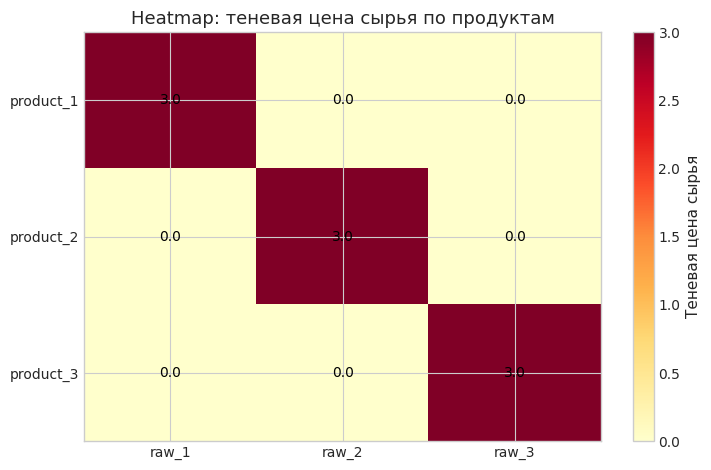

In [7]:
mu_matrix = raw_summary[["mu_raw_1", "mu_raw_2", "mu_raw_3"]].to_numpy()
mu_df = pd.DataFrame(mu_matrix, index=raw_summary["product"], columns=["raw_1", "raw_2", "raw_3"])
show_df(mu_df, "Матрица теневых цен сырья mu_{i,j}")

fig, ax = plt.subplots(figsize=(7.5, 4.8))
im = ax.imshow(mu_df.values, cmap="YlOrRd", aspect="auto")
ax.set_xticks(np.arange(mu_df.shape[1]), labels=mu_df.columns)
ax.set_yticks(np.arange(mu_df.shape[0]), labels=mu_df.index)
ax.set_title("Heatmap: теневая цена сырья по продуктам")

for i in range(mu_df.shape[0]):
    for j in range(mu_df.shape[1]):
        ax.text(j, i, f"{mu_df.values[i, j]:.1f}", ha="center", va="center", color="black")

cbar = plt.colorbar(im, ax=ax)
cbar.set_label("Теневая цена сырья")
plt.tight_layout()
plt.show()

## 11. Линейка сигналов: где видно завышение

### Целевая формула канала A (продукция)

$$
overpay_j = \max(0, p^{actual}_j - \pi_j)\cdot d_j
$$

#### Как формула конструируется

1. **Что оптимизируем/измеряем.** Здесь не оптимизация, а денежная оценка завышения по продукту $j$.
2. **Из чего складывается величина.** Разница цены `факт - fair`, обрезанная снизу нулём, затем умножение на объём.
3. **Почему `max(0, ...)`.** Если факт ниже fair, завышения нет, поэтому вклад не должен становиться отрицательным.
4. **Почему такие коэффициенты.** $\pi_j$ берётся из dual основной закупки как fair-ориентир продукта.
5. **Проверка размерности.** (цена - цена) × объём = деньги.
6. **Типичная ошибка.** Использовать просто `(p^{actual}_j - \pi_j)\cdot d_j` без `max`, тогда появятся отрицательные «переплаты».

### Целевая формула канала B (сырьё)

$$
overpay_{i,j} = \max(0, p^{actual}_{i,j} - \mu_{i,j})\cdot qty_{i,j}
$$

#### Как формула конструируется

1. **Что измеряем.** Денежный риск завышения сырья $i$ в контексте продукта $j$.
2. **Из чего складывается.** Та же логика: положительная часть разницы цен × объём закупки сырья.
3. **Почему `max(0, ...)`.** Завышение — это только превышение fair-ориентира, не его недобор.
4. **Почему такие коэффициенты.** $\mu_{i,j}$ — fair-ориентир сырья из dual сырьевой задачи.
5. **Проверка размерности.** Цена сырья × количество сырья = деньги.
6. **Типичная ошибка.** Подставить вместо $\mu_{i,j}$ глобальную цену из другого шага и потерять контекст продукта.

### Итоговая целевая формула риска

$$
total\_risk = \sum_j overpay_j + \sum_{i,j} overpay_{i,j}
$$

#### Как формула конструируется

1. **Что измеряем.** Общий потенциальный денежный риск по двум каналам.
2. **Из чего складывается сумма.** Отдельно по продуктам и отдельно по сырью, затем объединяем.
3. **Почему знак `+`.** Каналы независимы и оба добавляют риск; вычитать здесь нельзя.
4. **Почему такие коэффициенты.** Коэффициенты уже «внутри» `overpay` через объёмы и fair-цены.
5. **Проверка размерности.** Деньги + деньги = деньги.
6. **Типичная ошибка.** Смешать каналы и посчитать только один тип переплаты.

### Формула чтения сигнала

- если `delta_price <= 0`, модель не подтверждает завышение;
- если `delta_price > 0`, есть модельный сигнал;
- приоритет задают одновременно `overprice_pct` (интенсивность) и `overpay` (деньги).

### Подробная трактовка флагов

- `green`: отклонение небольшое; обычно достаточно мониторинга;
- `yellow`: отклонение заметное; нужна проверка обоснований цены и согласований;
- `red`: отклонение высокое; приоритетная проверка контрактов, спецификаций, первички и рыночных сопоставлений.

Флаг означает приоритет контроля, а не юридический вывод.

In [8]:
def audit_products(d: np.ndarray, pi: np.ndarray, actual_prod_prices: np.ndarray) -> pd.DataFrame:
    df = pd.DataFrame(
        {
            "product": ["product_1", "product_2", "product_3"],
            "qty": d,
            "fair_price_pi": pi,
            "actual_price": actual_prod_prices,
        }
    )
    df["delta_price"] = df["actual_price"] - df["fair_price_pi"]
    df["overpay"] = np.maximum(0.0, df["delta_price"]) * df["qty"]
    df["overprice_pct"] = np.where(
        df["fair_price_pi"] > 0,
        100.0 * df["delta_price"] / df["fair_price_pi"],
        np.nan,
    )
    df["flag"] = df["overprice_pct"].apply(risk_flag)
    return df


def audit_raws(mu_df: pd.DataFrame, actual_rows: pd.DataFrame) -> pd.DataFrame:
    fair_prices = []
    for _, row in actual_rows.iterrows():
        fair_prices.append(mu_df.loc[row["product"], row["raw"]])

    out = actual_rows.copy()
    out["fair_price_mu"] = fair_prices
    out["delta_price"] = out["actual_price"] - out["fair_price_mu"]
    out["overpay"] = np.maximum(0.0, out["delta_price"]) * out["qty"]
    out["overprice_pct"] = np.where(
        out["fair_price_mu"] > 0,
        100.0 * out["delta_price"] / out["fair_price_mu"],
        np.nan,
    )
    out["flag"] = out["overprice_pct"].apply(risk_flag)
    return out

## 12. Аудит завышений по видам продукции

### Что решаем
Проверяем, насколько фактические цены продукции выше fair-ориентиров $\pi$.

### Какие данные входят
- фактические контрактные цены:

$$
p^{actual}_{prod}=(140,\ 98,\ 127)
$$

- модельные fair-ориентиры $\pi$ из Dual-DP;
- объёмы закупки $d$.

### Что выходит
Таблица с `delta_price`, `overpay`, `overprice_pct`, `flag` по каждому продукту.

Ожидаемые переплаты:

$$
(11400,\ 2200,\ 1620),\quad \text{итого }15220
$$

### Как это используется дальше
Эта сумма идёт в общий риск-баланс и сравнивается с каналом сырья.

### Что сломается в логике, если шаг пропустить
Будет видно только сырьевой риск, а завышение на уровне готовых единиц продукции останется неоценённым.

### Куда смотреть после этапа: аудит по видам продукции

#### Ключевые числа этапа

| Метрика | Формула-источник | Где видно в коде/выводе | Ожидаемое значение | Критичный знак | Как трактовать отклонение |
|---|---|---|---|---|---|
| `delta_price` | $p^{actual}_j - \pi_j$ | `product_audit_df` | `>0` по всем 3 | знак разности | `<=0` — сигнала нет, `>0` — сигнал есть |
| `overprice_pct` | $100\cdot (p^{actual}_j-\pi_j)/\pi_j$ | `product_audit_df` | `37.25%`, `11.36%`, `7.63%` | знак числителя | Показывает интенсивность отклонения |
| `overpay` | $\max(0, p^{actual}_j-\pi_j)\cdot d_j$ | `product_audit_df` | `11400`, `2200`, `1620` | `max(0,...)` | Денежный вклад в риск |
| `flag` | Пороги по `%` | `product_audit_df` | `red`, `yellow`, `green` | пороговые неравенства | Очерёдность проверки документов |

#### Быстрый маршрут чтения формулы -> числа -> вывод
1. Смотрите `delta_price`: есть ли превышение fair-цены.
2. Смотрите `%`: насколько сильное превышение.
3. Смотрите `overpay`: где наибольший денежный эффект.

,product,qty,fair_price_pi,actual_price,delta_price,overpay,overprice_pct,flag
0,product_1,300.00,102.00,140.00,38.00,11400.00,37.25,red
1,product_2,220.00,88.00,98.00,10.00,2200.00,11.36,yellow
2,product_3,180.00,118.00,127.00,9.00,1620.00,7.63,green


Суммарная переплата по закупочным ценам продукции: 15220.0


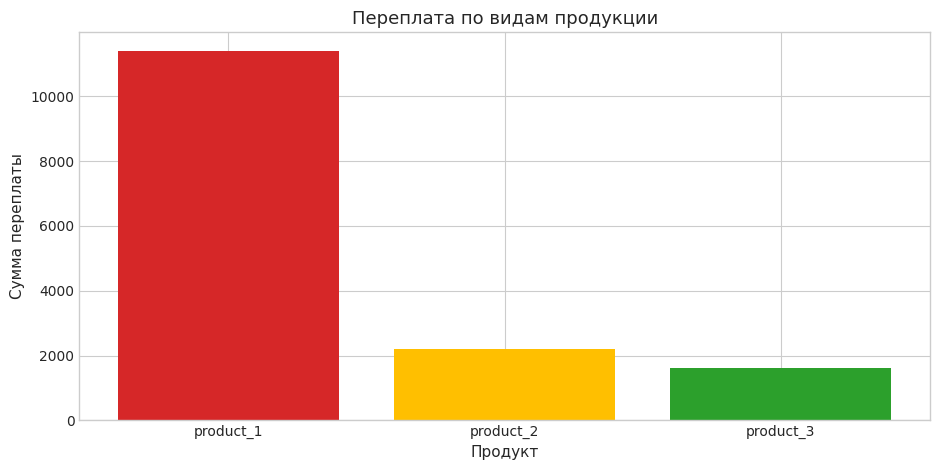

In [9]:
actual_prod_prices = np.array([140.0, 98.0, 127.0], dtype=float)
product_audit_df = audit_products(d=d, pi=pi, actual_prod_prices=actual_prod_prices)

show_df(product_audit_df.round(4), "Аудит по видам продукции")
print("Суммарная переплата по закупочным ценам продукции:", float(np.round(product_audit_df["overpay"].sum(), 2)))

fig, ax = plt.subplots(figsize=(9.5, 4.8))
bar_colors = product_audit_df["flag"].map({"red": "#d62728", "yellow": "#ffbf00", "green": "#2ca02c"})
ax.bar(product_audit_df["product"], product_audit_df["overpay"], color=bar_colors)
ax.set_title("Переплата по видам продукции")
ax.set_xlabel("Продукт")
ax.set_ylabel("Сумма переплаты")
plt.tight_layout()
plt.show()

## 13. Аудит завышений по критичному сырью

### Что решаем
Проверяем сырьевые цены в тех связках, где сырьё реально дефицитно в оптимуме ($\mu_{i,j}>0$).

### Какие данные входят
Берём только критичные пары «продукт–сырьё»:
- `product_1/raw_1`: fair $3$, actual $4.5$, qty $250$;
- `product_2/raw_2`: fair $3$, actual $4.2$, qty $180$;
- `product_3/raw_3`: fair $3$, actual $5.0$, qty $190$.

### Что выходит
Таблица переплат по сырью и их флаги.

Ожидаемый итог:

$$
971
$$

### Как это используется дальше
Сумма по сырью складывается с суммой по продукции в сводном риск-отчёте.

### Что сломается в логике, если шаг пропустить
Риск может быть скрыт в сырье даже при умеренных ценах по готовой продукции; без этого шага общий риск будет занижен.

### Куда смотреть после этапа: аудит по критичному сырью

#### Ключевые числа этапа

| Метрика | Формула-источник | Где видно в коде/выводе | Ожидаемое значение | Критичный знак | Как трактовать отклонение |
|---|---|---|---|---|---|
| `fair_price_mu` | $\mu_{i,j}$ из dual сырьевой задачи | `raw_audit_df` | `3`, `3`, `3` | ненулевой `\mu` | База сравнения для факта |
| `delta_price` | $p^{actual}_{i,j}-\mu_{i,j}$ | `raw_audit_df` | `>0` в 3/3 связках | знак разности | `>0` означает сигнал завышения |
| `overpay` | $\max(0, p^{actual}_{i,j}-\mu_{i,j})\cdot qty_{i,j}$ | `raw_audit_df` | `375`, `216`, `380` | `max(0,...)` | Денежный риск по связке сырьё/продукт |
| `flag` | Пороги по `%` | `raw_audit_df` | `red`, `red`, `red` | пороговые неравенства | Очерёдность детальной проверки |

#### Быстрый маршрут чтения формулы -> числа -> вывод
1. Берёте fair из `\mu`.
2. Сравниваете с фактом через `delta_price`.
3. Умножаете на объём и получаете денежный приоритет проверки.

,product,raw,qty,actual_price,fair_price_mu,delta_price,overpay,overprice_pct,flag
0,product_1,raw_1,250.00,4.50,3.00,1.50,375.00,50.00,red
1,product_2,raw_2,180.00,4.20,3.00,1.20,216.00,40.00,red
2,product_3,raw_3,190.00,5.00,3.00,2.00,380.00,66.67,red


Суммарная переплата по критичному сырью: 971.0


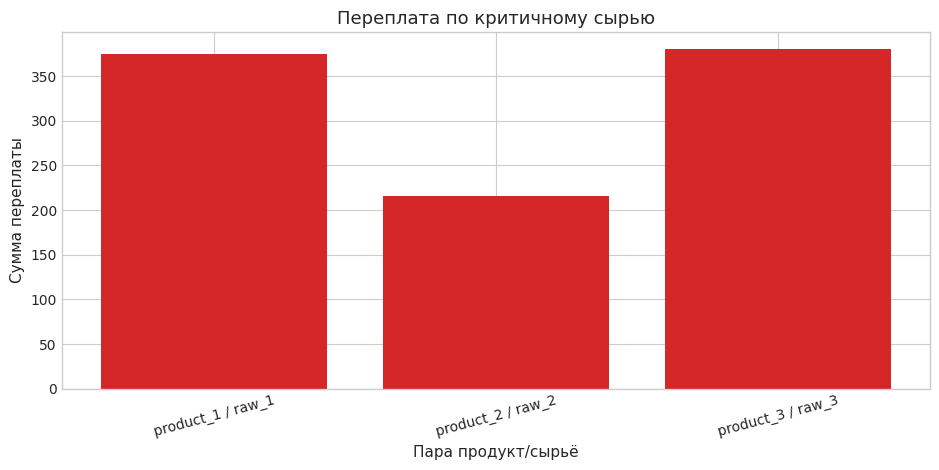

In [10]:
actual_raw_rows = pd.DataFrame(
    {
        "product": ["product_1", "product_2", "product_3"],
        "raw": ["raw_1", "raw_2", "raw_3"],
        "qty": [250.0, 180.0, 190.0],
        "actual_price": [4.5, 4.2, 5.0],
    }
)

raw_audit_df = audit_raws(mu_df=mu_df, actual_rows=actual_raw_rows)
show_df(raw_audit_df.round(4), "Аудит по критичному сырью")
print("Суммарная переплата по критичному сырью:", float(np.round(raw_audit_df["overpay"].sum(), 2)))

fig, ax = plt.subplots(figsize=(9.5, 4.8))
labels = raw_audit_df["product"] + " / " + raw_audit_df["raw"]
bar_colors = raw_audit_df["flag"].map({"red": "#d62728", "yellow": "#ffbf00", "green": "#2ca02c"})
ax.bar(labels, raw_audit_df["overpay"], color=bar_colors)
ax.set_title("Переплата по критичному сырью")
ax.set_xlabel("Пара продукт/сырьё")
ax.set_ylabel("Сумма переплаты")
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

## 14. Сводный риск-отчёт и структура ущерба

### Что решаем
Объединяем два канала: завышение по продукции и завышение по критичному сырью.

### Какие данные входят
- сумма `overpay` из аудита продукции;
- сумма `overpay` из аудита сырья.

### Что выходит
- общий потенциальный риск-объём;
- структура долей по каналам;
- наглядный приоритет дальнейшей проверки.

### Как это используется дальше
Итоговый отчёт переводится в управленческий план действий: что проверять в документах в первую очередь.

### Что сломается в логике, если шаг пропустить
Будут локальные результаты по каждому каналу, но не будет целостной оценки масштаба и приоритета проверки.

### Куда смотреть после этапа: сводный риск

#### Ключевые числа этапа

| Метрика | Формула-источник | Где видно в коде/выводе | Ожидаемое значение | Критичный знак | Как трактовать отклонение |
|---|---|---|---|---|---|
| `products_total` | $\sum_j overpay_j$ | Контрольные суммы | `15220` | сумма `+` | Риск-канал готовой продукции |
| `raw_total` | $\sum_{i,j} overpay_{i,j}$ | Контрольные суммы | `971` | сумма `+` | Риск-канал сырья |
| `overall_total` | $total\_risk = products\_total + raw\_total$ | Контрольные суммы | `16191` | итоговый `+` | Общий денежный ориентир проверки |

#### Быстрый маршрут чтения формулы -> числа -> вывод
1. Сначала смотрите две частные суммы (`products_total`, `raw_total`).
2. Затем смотрите `overall_total`.
3. После этого выбирайте, какой канал проверять первым по максимальному вкладу.

,channel,overpay
0,product_prices,15220.00
1,critical_raws,971.00
2,total,16191.00


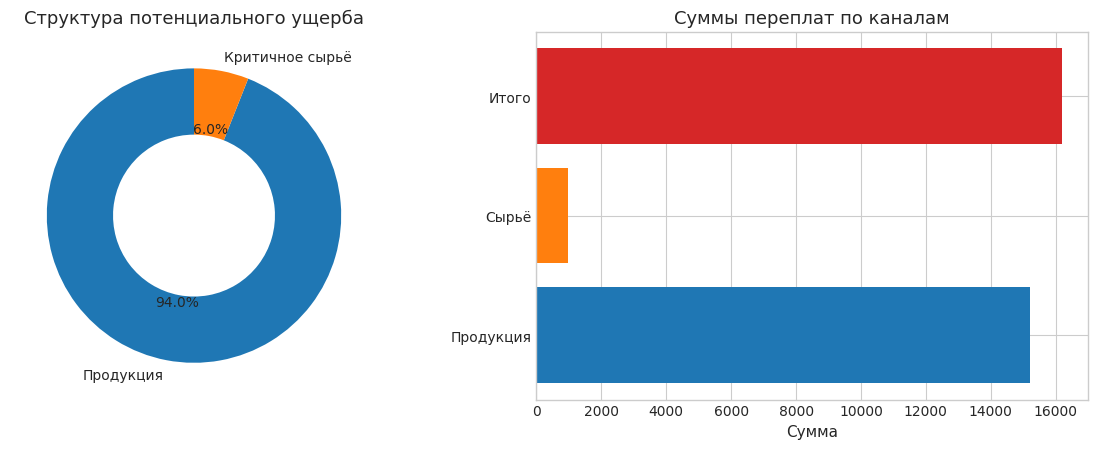

Контрольные итоговые суммы по каналам риска:
Переплата по продукции: 15220.0
Переплата по критичному сырью: 971.0
Общий потенциальный риск-объём: 16191.0


In [11]:
products_total = float(np.round(product_audit_df["overpay"].sum(), 2))
raw_total = float(np.round(raw_audit_df["overpay"].sum(), 2))
overall_total = float(np.round(products_total + raw_total, 2))

summary_df = pd.DataFrame(
    {
        "channel": ["product_prices", "critical_raws", "total"],
        "overpay": [products_total, raw_total, overall_total],
    }
)
show_df(summary_df.round(2), "Сводный денежный риск")

fig, axes = plt.subplots(1, 2, figsize=(12, 4.6))

# Pie of risk structure
axes[0].pie(
    [products_total, raw_total],
    labels=["Продукция", "Критичное сырьё"],
    autopct="%1.1f%%",
    colors=["#1f77b4", "#ff7f0e"],
    startangle=90,
    wedgeprops={"width": 0.45},
)
axes[0].set_title("Структура потенциального ущерба")

# Horizontal bar for totals
axes[1].barh(["Продукция", "Сырьё", "Итого"], [products_total, raw_total, overall_total], color=["#1f77b4", "#ff7f0e", "#d62728"])
axes[1].set_title("Суммы переплат по каналам")
axes[1].set_xlabel("Сумма")

plt.tight_layout()
plt.show()

print("Контрольные итоговые суммы по каналам риска:")
print("Переплата по продукции:", products_total)
print("Переплата по критичному сырью:", raw_total)
print("Общий потенциальный риск-объём:", overall_total)

## 15. Автопроверка контрольных значений

In [12]:
# Основная задача
assert np.isclose(C_min, 68740.0)
assert np.isclose(Psi_max, 68740.0)
assert np.allclose(pi, np.array([102.0, 88.0, 118.0]))
assert np.allclose(Q_opt, np.array([[180.0, 80.0, 0.0], [20.0, 140.0, 60.0], [100.0, 0.0, 120.0]]))

# Три задачи по сырью
expected_F = np.array([7530.0, 5360.0, 7260.0])
expected_mu = np.array([[3.0, 0.0, 0.0], [0.0, 3.0, 0.0], [0.0, 0.0, 3.0]])
assert np.allclose(raw_summary["F_min"].to_numpy(), expected_F)
assert np.allclose(mu_df.to_numpy(), expected_mu)

# Аудит
assert np.allclose(product_audit_df["overpay"].to_numpy(), np.array([11400.0, 2200.0, 1620.0]))
assert np.isclose(products_total, 15220.0)
assert np.isclose(raw_total, 971.0)
assert np.isclose(overall_total, 16191.0)

print("Проверка завершена: все контрольные условия выполнены корректно.")

Проверка завершена: все контрольные условия выполнены корректно.


## 16. Дашборд чтения результатов: что смотреть в первую очередь

### Панель приоритета (5 чисел)

1. `pi` — fair-ориентир по видам продукции: смотреть перед аудитом продукции.
2. `mu` — fair-ориентир по сырью в контексте продукта: смотреть перед аудитом сырья.
3. `overpay` по продукции — где самый большой денежный риск по готовым единицам.
4. `overpay` по сырью — где есть дополнительный риск в критичных сырьевых связках.
5. `overall_total` — общий потенциальный риск-объём для управленческого решения.

### Если времени 2 минуты

- Самый большой денежный риск в этом кейсе: канал продукции (`15220`) больше канала сырья (`971`).
- Самый высокий процент отклонения: среди сырьевых позиций (все `red`), а по продукции максимальное отклонение у `product_1`.
- Какие документы поднимать первыми: контракты и спецификации по позициям с максимальными `overpay` и `overprice_pct`, затем согласования цены и рыночные обоснования.

### Чек-лист действий для контроля

1. Сначала проверяем соответствие `actual_price` против fair-ориентиров (`pi` и `mu`).
2. Затем ранжируем позиции по `overpay` (деньги) и `overprice_pct` (интенсивность отклонения).
3. Потом применяем флаги: `red` — приоритет 1, `yellow` — приоритет 2, `green` — мониторинг.
4. После этого формируем план документальной проверки и фиксируем итог `overall_total = 16191` как стартовый риск-ориентир.

Финальный смысл: модель показывает не обвинение, а понятную числовую очередь проверки — где вероятность завышения выше и где потенциальный денежный эффект больше.

## 17. Дополнительная информация

### Внутри ноутбука (быстрые переходы)

- [Основная задача закупки (Primal-P)](#1-основная-задача-госзакупки-primal-p)
- [Двойственная задача (Dual-DP)](#2-двойственная-задача-к-основной-закупке-dual-dp)
- [Сырьевые задачи по продуктам](#3-отдельные-задачи-по-сырью-для-каждого-продукта)
- [Переход к `linprog` без магии](#31-переход-к-формату-linprog-без-магии)
- [Линейка сигналов завышения](#11-линейка-сигналов-где-видно-завышение)
- [Дашборд чтения результатов](#16-дашборд-чтения-результатов-что-смотреть-в-первую-очередь)

### Внешние проверенные источники

1. SciPy `linprog` (официальная документация):
   https://docs.scipy.org/doc/scipy/reference/generated/scipy.optimize.linprog.html
   Зачем читать: официальный формат входа (`A_ub`, `b_ub`, `bounds`) и интерпретация результата (`x`, `fun`, `success`).

2. HiGHS Documentation:
   https://ergo-code.github.io/HiGHS/dev/
   Зачем читать: что именно делает решатель `highs` и почему он используется как основной метод.

3. MIT OpenCourseWare, курс по оптимизации (прямые/двойственные идеи):
   https://ocw.mit.edu/courses/15-053-optimization-methods-in-management-science-spring-2013/
   Зачем читать: интуиция и базовая теория по LP и dual-подходу на учебном материале.

Если нужно углубление, полезно читать источники в порядке: сначала SciPy (практика), потом HiGHS (решатель), затем курс по теории (почему это работает математически).